# H₂ Yield Prediction from Dark Fermentation Process Parameters

## Notebook 04: Synthetic Data Validation

### Objective

The optimized bootstrap jitter generator produced a balanced synthetic dataset containing 6,000 observations across six F/M ratios.

Although the synthetic generation strategy was selected through comparative generator benchmarking and jitter-factor optimization, the final generated dataset must be independently validated before predictive model development.

The objective of this notebook is to evaluate whether the synthetic dataset preserves the statistical and multivariate characteristics of the quality-controlled experimental reference data.

The validation framework includes:

1. Dataset structure verification.
2. F/M group balance assessment.
3. Group-wise descriptive statistical comparison.
4. Mean preservation analysis.
5. Standard deviation preservation analysis.
6. Median and interquartile range comparison.
7. H₂ yield distribution validation.
8. Correlation structure preservation.
9. F/M-specific H₂ yield pattern validation.
10. Quantitative statistical fidelity assessment.

The synthetic dataset will proceed to machine learning model development only after its statistical characteristics have been systematically evaluated against the experimental reference dataset.

## 1. Import Required Libraries

Libraries required for data manipulation, numerical analysis, statistical evaluation, and visualization are imported.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:.3f}"
)

## 2. Load the Experimental Reference and Synthetic Datasets

The quality-controlled experimental reference dataset and the final synthetic H₂ dataset are loaded.

The experimental reference dataset contains 61 quality-controlled observations.

The synthetic dataset contains 6,000 observations generated using the optimized bootstrap jitter method with a perturbation factor of 0.08.

In [2]:
reference_path = (
    r"D:\Data Science Projects\Hydrogen yield predictor"
    r"\data\reference_experimental_data.csv"
)

synthetic_path = (
    r"D:\Data Science Projects\Hydrogen yield predictor"
    r"\data\h2_data.csv"
)

reference_raw = pd.read_csv(reference_path)
synthetic_raw = pd.read_csv(synthetic_path)

print("Datasets loaded successfully.")

print(
    "\nReference dataset shape:",
    reference_raw.shape
)

print(
    "Synthetic dataset shape:",
    synthetic_raw.shape
)

Datasets loaded successfully.

Reference dataset shape: (61, 27)
Synthetic dataset shape: (6000, 17)


## 3. Select Variables for Synthetic Data Validation

The experimental reference dataset contains additional diagnostic variables generated during the data-quality audit.

Only the original experimental variables used in synthetic data generation and H₂ yield prediction are retained for validation.

The treatment identifier and data-quality diagnostic variables are excluded.

In [3]:
experimental_columns = [
    "substrate_mc",
    "substrate_ts",
    "substrate_vs",
    "substrate_fs",
    "inoculum_mc",
    "inoculum_ts",
    "inoculum_vs",
    "inoculum_fs",
    "scod",
    "tcod",
    "scod_tcod_ratio",
    "trs",
    "lignin",
    "hmf",
    "fm_ratio",
    "h2_yield"
]

reference_df = reference_raw[
    experimental_columns
].copy()

synthetic_df = synthetic_raw[
    experimental_columns
].copy()

print(
    "Reference validation dataset shape:",
    reference_df.shape
)

print(
    "Synthetic validation dataset shape:",
    synthetic_df.shape
)

Reference validation dataset shape: (61, 16)
Synthetic validation dataset shape: (6000, 16)


## 4. Verify Dataset Structure

The column structure of the experimental and synthetic datasets is compared before statistical validation.

Both datasets should contain the same variables in an identical order.

Missing values are also evaluated because incomplete synthetic observations could affect subsequent statistical and machine learning analyses.

In [4]:
structure_check = (
    list(reference_df.columns)
    == list(synthetic_df.columns)
)

reference_missing = (
    reference_df.isnull().sum().sum()
)

synthetic_missing = (
    synthetic_df.isnull().sum().sum()
)

print(
    "Identical dataset structure:",
    structure_check
)

print(
    "Reference missing values:",
    reference_missing
)

print(
    "Synthetic missing values:",
    synthetic_missing
)

Identical dataset structure: True
Reference missing values: 0
Synthetic missing values: 0


In [5]:
def calculate_validation_statistics(data, columns):
    
    records = []
    
    for fm_value, group in data.groupby("fm_ratio"):
        
        for column in columns:
            
            series = group[column]
            
            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            
            records.append({
                "fm_ratio": fm_value,
                "variable": column,
                "mean": series.mean(),
                "std": series.std(),
                "median": series.median(),
                "q1": q1,
                "q3": q3,
                "iqr": q3 - q1,
                "min": series.min(),
                "max": series.max(),
                "cv_percent": (
                    series.std() / abs(series.mean()) * 100
                    if series.mean() != 0
                    else np.nan
                ),
                "skewness": series.skew(),
                "kurtosis": series.kurt()
            })
    
    return pd.DataFrame(records)

In [6]:
statistical_columns = [
    "substrate_mc",
    "substrate_ts",
    "substrate_vs",
    "substrate_fs",
    "inoculum_mc",
    "inoculum_ts",
    "inoculum_vs",
    "inoculum_fs",
    "scod",
    "tcod",
    "scod_tcod_ratio",
    "trs",
    "lignin",
    "hmf",
    "h2_yield"
]

print(
    "Number of validation variables:",
    len(statistical_columns)
)

Number of validation variables: 15


In [7]:
reference_statistics = calculate_validation_statistics(
    reference_df,
    statistical_columns
)

synthetic_statistics = calculate_validation_statistics(
    synthetic_df,
    statistical_columns
)

print(
    "Reference statistics shape:",
    reference_statistics.shape
)

print(
    "Synthetic statistics shape:",
    synthetic_statistics.shape
)

Reference statistics shape: (90, 13)
Synthetic statistics shape: (90, 13)


In [8]:
statistical_comparison = (
    reference_statistics.merge(
        synthetic_statistics,
        on=["fm_ratio", "variable"],
        suffixes=(
            "_experimental",
            "_synthetic"
        )
    )
)

print(
    "Statistical comparison shape:",
    statistical_comparison.shape
)

statistical_comparison.head()

Statistical comparison shape: (90, 24)


,fm_ratio,variable,mean_experimental,std_experimental,median_experimental,q1_experimental,q3_experimental,iqr_experimental,min_experimental,max_experimental,cv_percent_experimental,skewness_experimental,kurtosis_experimental,mean_synthetic,std_synthetic,median_synthetic,q1_synthetic,q3_synthetic,iqr_synthetic,min_synthetic,max_synthetic,cv_percent_synthetic,skewness_synthetic,kurtosis_synthetic
0,0.500,substrate_mc,5.725,0.418,5.870,5.435,5.995,0.560,5.000,6.230,7.309,-0.521,-0.952,5.745,0.395,5.887,5.523,6.020,0.498,4.929,6.324,6.878,-0.514,-0.955
1,0.500,substrate_ts,94.275,0.418,94.130,94.005,94.565,0.560,93.770,95.000,0.444,0.521,-0.952,94.255,0.395,94.113,93.980,94.477,0.498,93.676,95.071,0.419,0.514,-0.955
2,0.500,substrate_vs,83.065,4.305,83.800,79.095,86.110,7.015,76.590,89.220,5.182,-0.070,-1.364,82.918,4.092,83.668,78.875,86.831,7.956,75.789,90.038,4.934,-0.039,-1.286
3,0.500,substrate_fs,16.935,4.305,16.200,13.890,20.905,7.015,10.780,23.410,25.420,0.070,-1.364,17.082,4.092,16.332,13.169,21.125,7.956,9.962,24.211,23.953,0.039,-1.286
4,0.500,inoculum_mc,91.094,2.730,90.900,89.085,93.055,3.970,87.410,95.120,2.997,0.115,-1.275,90.942,2.581,90.879,88.738,92.691,3.953,86.785,95.560,2.838,0.121,-1.213


## 5. Quantify Statistical Fidelity Errors

The statistical characteristics of the synthetic dataset are compared with the corresponding experimental reference statistics.

Relative error can become unstable when an experimental statistic approaches zero. Therefore, scale-normalized absolute errors are calculated for the primary distribution statistics.

The validation focuses on:

- Mean
- Standard deviation
- Median
- Interquartile range

Lower error values indicate closer agreement between the experimental and synthetic datasets.

In [9]:
epsilon = 1e-8

statistical_comparison["mean_error"] = (
    abs(
        statistical_comparison["mean_synthetic"]
        - statistical_comparison["mean_experimental"]
    )
    /
    (
        abs(statistical_comparison["mean_experimental"])
        + epsilon
    )
)

statistical_comparison["std_error"] = (
    abs(
        statistical_comparison["std_synthetic"]
        - statistical_comparison["std_experimental"]
    )
    /
    (
        statistical_comparison["std_experimental"]
        + epsilon
    )
)

statistical_comparison["median_error"] = (
    abs(
        statistical_comparison["median_synthetic"]
        - statistical_comparison["median_experimental"]
    )
    /
    (
        abs(statistical_comparison["mean_experimental"])
        + epsilon
    )
)

statistical_comparison["iqr_error"] = (
    abs(
        statistical_comparison["iqr_synthetic"]
        - statistical_comparison["iqr_experimental"]
    )
    /
    (
        statistical_comparison["std_experimental"]
        + epsilon
    )
)

print("Statistical fidelity errors calculated successfully.")

Statistical fidelity errors calculated successfully.


## 6. Summarize Overall Statistical Fidelity

The normalized statistical errors are summarized across all experimental variables and F/M ratios.

The mean normalized error is calculated independently for the mean, standard deviation, median, and interquartile range.

An overall core validation error is subsequently calculated to provide a consolidated measure of synthetic data fidelity across the primary distribution characteristics.

In [10]:
overall_fidelity_summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Standard Deviation",
        "Median",
        "Interquartile Range"
    ],
    "Mean Normalized Error": [
        statistical_comparison["mean_error"].mean(),
        statistical_comparison["std_error"].mean(),
        statistical_comparison["median_error"].mean(),
        statistical_comparison["iqr_error"].mean()
    ]
})

overall_fidelity_summary

,Statistic,Mean Normalized Error
0,Mean,0.006
1,Standard Deviation,0.048
2,Median,0.006
3,Interquartile Range,0.156


## 7. Evaluate H₂ Yield Statistical Fidelity

H₂ yield represents the target variable of the subsequent predictive modelling workflow.

The experimental and synthetic H₂ yield distributions are compared independently across the six F/M ratios.

The analysis evaluates preservation of the mean, standard deviation, median, and interquartile range of H₂ yield within each experimental condition.

In [11]:
h2_validation = statistical_comparison[
    statistical_comparison["variable"] == "h2_yield"
][
    [
        "fm_ratio",
        "mean_experimental",
        "mean_synthetic",
        "std_experimental",
        "std_synthetic",
        "median_experimental",
        "median_synthetic",
        "iqr_experimental",
        "iqr_synthetic",
        "mean_error",
        "std_error",
        "median_error",
        "iqr_error"
    ]
].copy()

h2_validation

,fm_ratio,mean_experimental,mean_synthetic,std_experimental,std_synthetic,median_experimental,median_synthetic,iqr_experimental,iqr_synthetic,mean_error,std_error,median_error,iqr_error
14,0.500,19.526,19.079,7.189,7.031,21.150,20.864,3.600,3.586,0.023,0.022,0.015,0.002
29,1.000,82.040,82.659,15.557,14.867,86.630,86.208,23.700,24.550,0.008,0.044,0.005,0.055
44,1.500,122.931,122.790,22.958,21.208,110.650,111.452,28.810,30.692,0.001,0.076,0.007,0.082
59,2.000,372.909,368.905,114.788,110.679,396.775,392.473,76.403,90.173,0.011,0.036,0.012,0.120
74,2.500,272.271,275.513,48.677,45.563,286.035,289.439,73.605,85.595,0.012,0.064,0.013,0.246
89,3.000,167.329,168.662,59.004,54.561,173.045,173.800,35.000,40.192,0.008,0.075,0.005,0.088


### Interpretation of H₂ Yield Statistical Fidelity

The synthetic dataset demonstrated strong preservation of the group-specific H₂ yield characteristics.

Mean H₂ yield errors remained below 2.3% across all six F/M ratios. Median errors were also low, indicating close preservation of the central tendency of the experimental H₂ yield distributions.

Standard deviation errors remained below approximately 7.6%, demonstrating generally strong preservation of within-group variability.

The largest statistical deviation was observed for the H₂ yield interquartile range at F/M 2.5. The synthetic IQR was higher than the experimental reference, producing a normalized IQR error of 0.246. This indicates increased dispersion within the middle 50% of the synthetic H₂ yield observations for this group.

Despite this localized deviation, the synthetic dataset closely preserved the overall F/M-specific H₂ yield pattern, including the increase in hydrogen yield up to F/M 2.0 and the subsequent decline at higher F/M ratios.

The H₂ yield fidelity results therefore support continued multivariate and correlation-based validation of the synthetic dataset.

## 8. Compare the F/M-Specific H₂ Yield Response

The experimental and synthetic mean H₂ yields are compared across the six F/M ratios.

Preservation of the non-linear F/M response is particularly important because F/M ratio represents a major experimental condition in the subsequent H₂ yield prediction model.

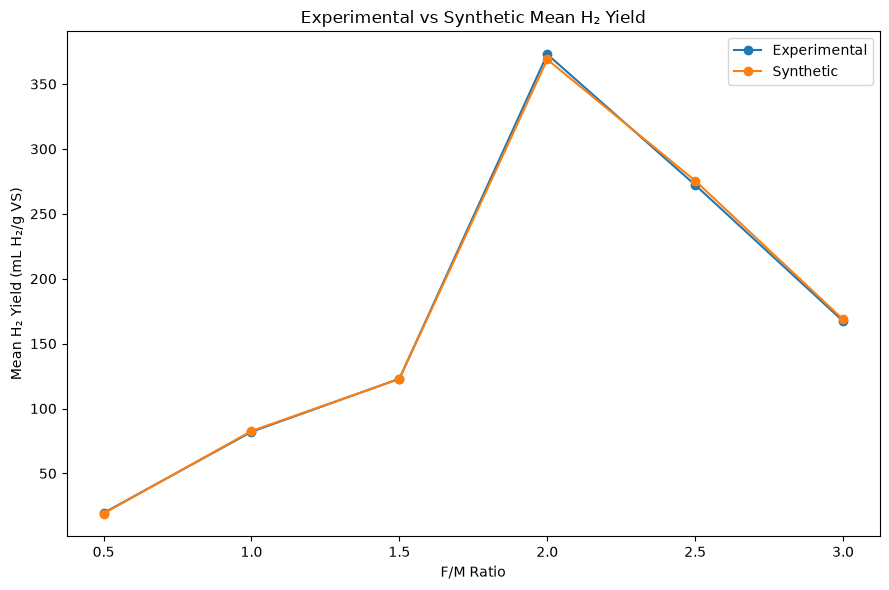

In [12]:
h2_mean_comparison = h2_validation[
    [
        "fm_ratio",
        "mean_experimental",
        "mean_synthetic"
    ]
].copy()

plt.figure(figsize=(9, 6))

plt.plot(
    h2_mean_comparison["fm_ratio"],
    h2_mean_comparison["mean_experimental"],
    marker="o",
    label="Experimental"
)

plt.plot(
    h2_mean_comparison["fm_ratio"],
    h2_mean_comparison["mean_synthetic"],
    marker="o",
    label="Synthetic"
)

plt.xlabel("F/M Ratio")
plt.ylabel("Mean H₂ Yield (mL H₂/g VS)")
plt.title("Experimental vs Synthetic Mean H₂ Yield")

plt.legend()
plt.tight_layout()
plt.show()

## 9. Evaluate Correlation Structure Preservation

Preservation of multivariate relationships is essential because the final machine learning model will predict H₂ yield using multiple experimental parameters.

The Pearson correlation matrices of the experimental and synthetic datasets are compared.

The absolute difference between corresponding correlation coefficients is calculated to quantify changes in the multivariate relationship structure.

In [13]:
reference_correlation = reference_df.corr()

synthetic_correlation = synthetic_df.corr()

correlation_difference = abs(
    synthetic_correlation
    - reference_correlation
)

correlation_difference

,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,fm_ratio,h2_yield
substrate_mc,0.000,0.000,0.036,0.036,0.037,0.037,0.013,0.013,0.008,0.007,0.003,0.005,0.028,0.018,0.029,0.024
substrate_ts,0.000,0.000,0.036,0.036,0.037,0.037,0.013,0.013,0.008,0.007,0.003,0.005,0.028,0.018,0.029,0.024
substrate_vs,0.036,0.036,0.000,0.000,0.005,0.005,0.016,0.016,0.015,0.005,0.009,0.003,0.013,0.001,0.012,0.006
substrate_fs,0.036,0.036,0.000,0.000,0.005,0.005,0.016,0.016,0.015,0.005,0.009,0.003,0.013,0.001,0.012,0.006
inoculum_mc,0.037,0.037,0.005,0.005,0.000,0.000,0.007,0.007,0.002,0.006,0.002,0.017,0.024,0.004,0.025,0.018
inoculum_ts,0.037,0.037,0.005,0.005,0.000,0.000,0.007,0.007,0.002,0.006,0.002,0.017,0.024,0.004,0.025,0.018
inoculum_vs,0.013,0.013,0.016,0.016,0.007,0.007,0.000,0.000,0.016,0.007,0.002,0.015,0.001,0.013,0.007,0.012
inoculum_fs,0.013,0.013,0.016,0.016,0.007,0.007,0.000,0.000,0.016,0.007,0.002,0.015,0.001,0.013,0.007,0.012
scod,0.008,0.008,0.015,0.015,0.002,0.002,0.016,0.016,0.000,0.027,0.020,0.008,0.030,0.025,0.002,0.003
tcod,0.007,0.007,0.005,0.005,0.006,0.006,0.007,0.007,0.027,0.000,0.006,0.001,0.002,0.010,0.005,0.010


In [14]:
correlation_mask = ~np.eye(
    len(reference_correlation),
    dtype=bool
)

mean_correlation_error = (
    correlation_difference
    .values[correlation_mask]
    .mean()
)

max_correlation_error = (
    correlation_difference
    .values[correlation_mask]
    .max()
)

print(
    "Mean Absolute Correlation Error:",
    round(mean_correlation_error, 4)
)

print(
    "Maximum Absolute Correlation Error:",
    round(max_correlation_error, 4)
)

Mean Absolute Correlation Error: 0.0124
Maximum Absolute Correlation Error: 0.0373


### Interpretation of Correlation Structure Fidelity

The synthetic dataset demonstrated strong preservation of the experimental correlation structure.

The mean absolute correlation error was 0.0124, indicating that corresponding experimental and synthetic correlation coefficients differed by approximately 0.012 correlation units on average.

The maximum absolute correlation error was 0.0373. Therefore, no individual pairwise relationship exhibited a correlation deviation greater than approximately 0.04.

These results indicate that the optimized bootstrap jitter generator closely preserved the multivariate relationships present in the experimental reference dataset.

The low mean and maximum correlation errors support the use of the synthetic dataset for further target-specific relationship analysis.

## 10. Visualize Correlation Structure Differences

The absolute differences between the experimental and synthetic Pearson correlation matrices are visualized using a heatmap.

Values approaching zero indicate close preservation of the corresponding experimental variable relationship.

The visualization is used to identify whether correlation deviations are broadly distributed or concentrated within specific variable pairs.

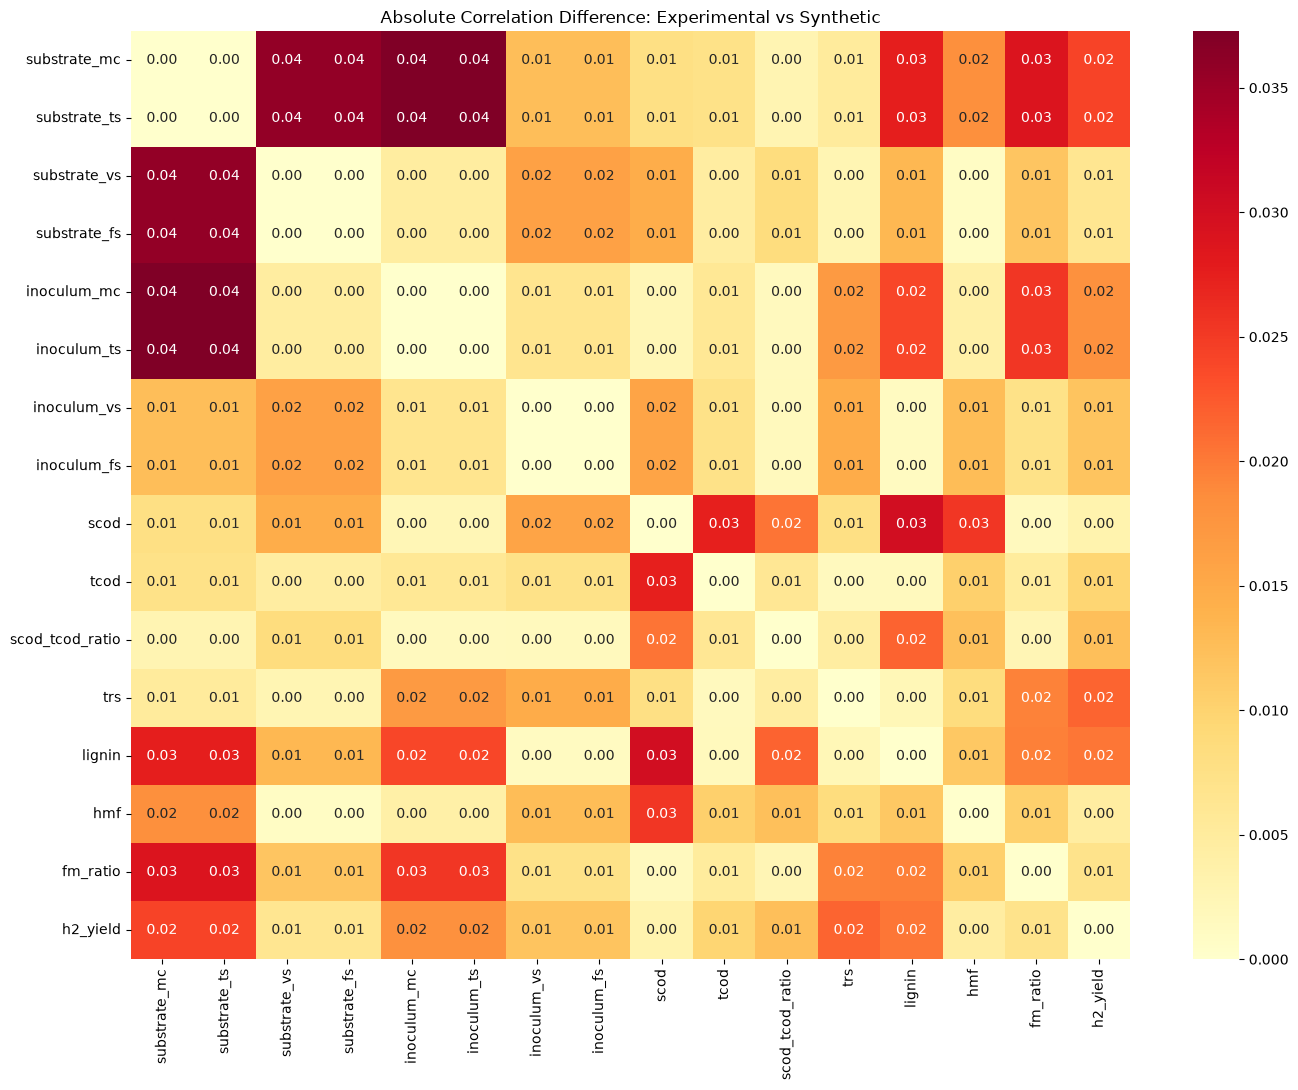

In [15]:
plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_difference,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title(
    "Absolute Correlation Difference: Experimental vs Synthetic"
)

plt.tight_layout()
plt.show()

## 11. Evaluate H₂ Yield Correlation Preservation

Because H₂ yield is the target variable of the predictive modelling workflow, its relationships with the experimental predictor variables are evaluated separately.

Experimental and synthetic Pearson correlations with H₂ yield are compared directly.

The absolute correlation difference is calculated for each predictor to determine whether target-specific multivariate relationships were preserved during synthetic data generation.

In [16]:
h2_correlation_comparison = pd.DataFrame({
    "Experimental Correlation": (
        reference_correlation["h2_yield"]
    ),
    "Synthetic Correlation": (
        synthetic_correlation["h2_yield"]
    )
})

h2_correlation_comparison[
    "Absolute Difference"
] = abs(
    h2_correlation_comparison[
        "Synthetic Correlation"
    ]
    - h2_correlation_comparison[
        "Experimental Correlation"
    ]
)

h2_correlation_comparison = (
    h2_correlation_comparison
    .drop(index="h2_yield")
    .sort_values(
        "Absolute Difference",
        ascending=False
    )
)

h2_correlation_comparison

,Experimental Correlation,Synthetic Correlation,Absolute Difference
substrate_mc,0.403,0.378,0.024
substrate_ts,-0.403,-0.378,0.024
trs,0.304,0.282,0.022
lignin,-0.617,-0.596,0.020
inoculum_mc,-0.160,-0.142,0.018
inoculum_ts,0.160,0.142,0.018
scod_tcod_ratio,0.023,0.011,0.012
inoculum_fs,0.331,0.343,0.012
inoculum_vs,-0.331,-0.343,0.012
tcod,-0.039,-0.029,0.010


## 12. Visualize H₂ Yield Correlation Preservation

Experimental and synthetic correlations between the predictor variables and H₂ yield are visualized for direct comparison.

Close agreement between the paired bars indicates preservation of target-specific relationships relevant to subsequent predictive modelling.

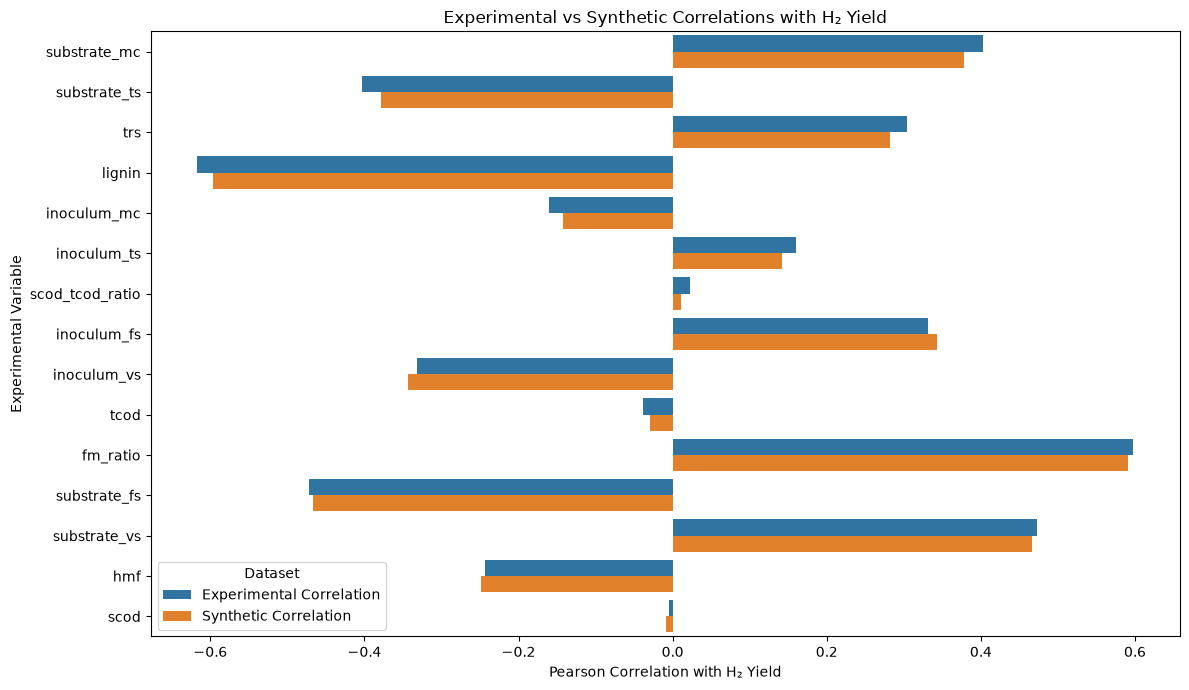

In [17]:
h2_corr_plot = (
    h2_correlation_comparison
    .reset_index()
    .rename(columns={"index": "Variable"})
)

h2_corr_long = h2_corr_plot.melt(
    id_vars="Variable",
    value_vars=[
        "Experimental Correlation",
        "Synthetic Correlation"
    ],
    var_name="Dataset",
    value_name="Correlation"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=h2_corr_long,
    x="Correlation",
    y="Variable",
    hue="Dataset"
)

plt.xlabel("Pearson Correlation with H₂ Yield")
plt.ylabel("Experimental Variable")
plt.title(
    "Experimental vs Synthetic Correlations with H₂ Yield"
)

plt.tight_layout()
plt.show()

### Interpretation of H₂ Yield Correlation Preservation

The synthetic dataset closely preserved the experimental relationships between the predictor variables and H₂ yield.

The strongest experimental associations, including the positive relationships of F/M ratio and substrate volatile solids with H₂ yield and the negative relationships of lignin and substrate fixed solids with H₂ yield, were reproduced in the synthetic dataset.

The direction of the major H₂ yield correlations remained consistent between the experimental and synthetic datasets.

Variables exhibiting comparatively weak experimental relationships with H₂ yield, including sCOD and the sCOD/TCOD ratio, also retained relatively weak correlations in the synthetic dataset.

The close agreement between experimental and synthetic target correlations indicates that the bootstrap jitter generation procedure preserved the major multivariate relationships relevant to H₂ yield prediction.

## 13. Quantify H₂ Yield Correlation Fidelity

The preservation of target-specific relationships is quantified using the mean and maximum absolute differences between experimental and synthetic correlations with H₂ yield.

These metrics provide a concise assessment of whether the synthetic generation process altered relationships involving the predictive target.

In [18]:
mean_h2_correlation_error = (
    h2_correlation_comparison[
        "Absolute Difference"
    ].mean()
)

max_h2_correlation_error = (
    h2_correlation_comparison[
        "Absolute Difference"
    ].max()
)

max_h2_correlation_variable = (
    h2_correlation_comparison[
        "Absolute Difference"
    ].idxmax()
)

print(
    "Mean H₂ Correlation Error:",
    round(mean_h2_correlation_error, 4)
)

print(
    "Maximum H₂ Correlation Error:",
    round(max_h2_correlation_error, 4)
)

print(
    "Variable with Maximum H₂ Correlation Error:",
    max_h2_correlation_variable
)

Mean H₂ Correlation Error: 0.0133
Maximum H₂ Correlation Error: 0.0242
Variable with Maximum H₂ Correlation Error: substrate_mc


## 14. Compare F/M-Specific H₂ Yield Distributions

The experimental and synthetic H₂ yield distributions are compared independently within each F/M ratio.

Boxplots are used to evaluate preservation of group-specific central tendency, variability, and the overall non-linear H₂ yield response across the experimental F/M conditions.

Because the synthetic dataset contains substantially more observations than the experimental reference dataset, the comparison focuses on distributional characteristics rather than observation counts.

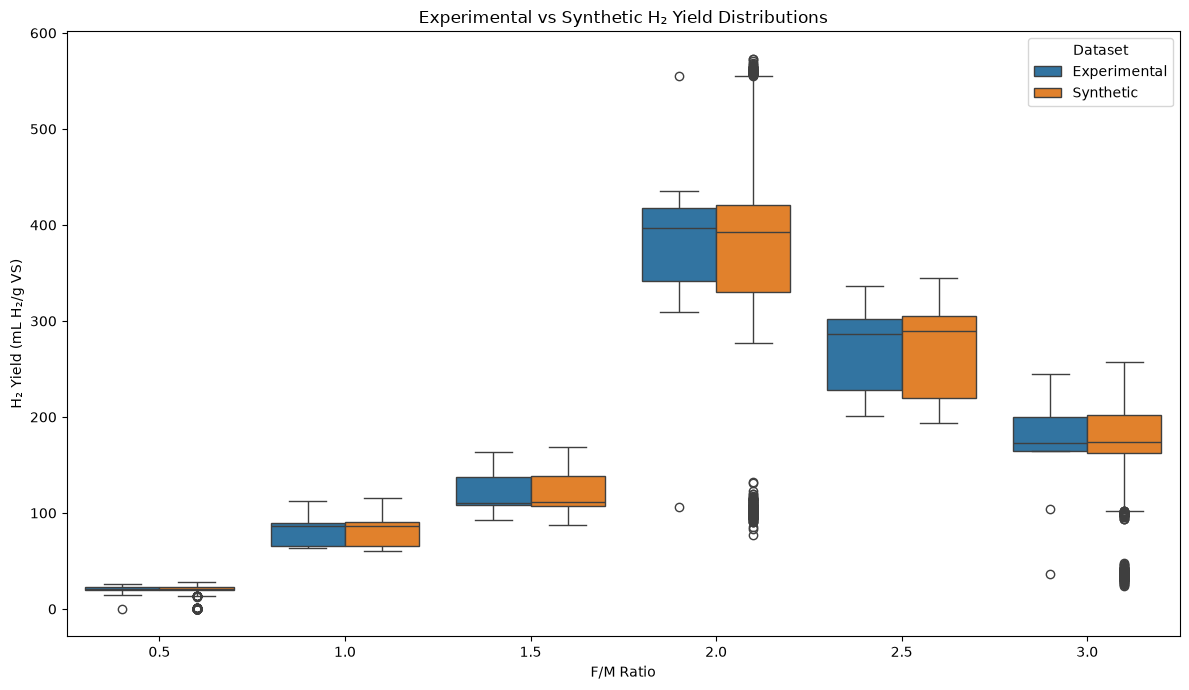

In [19]:
reference_h2_plot = reference_df[
    ["fm_ratio", "h2_yield"]
].copy()

reference_h2_plot["Dataset"] = "Experimental"

synthetic_h2_plot = synthetic_df[
    ["fm_ratio", "h2_yield"]
].copy()

synthetic_h2_plot["Dataset"] = "Synthetic"

combined_h2_plot = pd.concat(
    [
        reference_h2_plot,
        synthetic_h2_plot
    ],
    ignore_index=True
)

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=combined_h2_plot,
    x="fm_ratio",
    y="h2_yield",
    hue="Dataset"
)

plt.xlabel("F/M Ratio")
plt.ylabel("H₂ Yield (mL H₂/g VS)")
plt.title(
    "Experimental vs Synthetic H₂ Yield Distributions"
)

plt.tight_layout()
plt.show()

### Interpretation of H₂ Yield Correlation Fidelity

The synthetic dataset demonstrated strong preservation of target-specific multivariate relationships.

The mean absolute difference between experimental and synthetic correlations with H₂ yield was 0.0133.

The maximum target-correlation difference was 0.0242 and was associated with substrate moisture content.

These low correlation errors indicate that the major relationships between the experimental predictor variables and H₂ yield were closely preserved during synthetic data generation.

However, visual comparison of the F/M-specific H₂ yield distributions identified clusters of synthetic extreme observations at selected F/M ratios.

Because bootstrap sampling may repeatedly select rare experimental observations, an additional outlier-frequency analysis is performed before final validation.

## 15. Evaluate H₂ Yield Outlier Frequency

Bootstrap-based synthetic generation may repeatedly sample rare experimental observations.

Although numerical perturbation prevents exact duplication, repeated selection of an extreme experimental observation may produce clusters of synthetic observations around the original extreme value.

The frequency of H₂ yield outliers is therefore compared between the experimental and synthetic datasets.

Experimental group-specific interquartile range boundaries are used as fixed reference thresholds for both datasets.

This ensures that synthetic observations are evaluated relative to the experimentally observed distribution.

In [20]:
outlier_records = []

for fm_value, experimental_group in reference_df.groupby(
    "fm_ratio"
):
    
    synthetic_group = synthetic_df[
        synthetic_df["fm_ratio"] == fm_value
    ]
    
    q1 = experimental_group["h2_yield"].quantile(0.25)
    q3 = experimental_group["h2_yield"].quantile(0.75)
    
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    experimental_outliers = (
        (
            experimental_group["h2_yield"] < lower_bound
        )
        |
        (
            experimental_group["h2_yield"] > upper_bound
        )
    ).sum()
    
    synthetic_outliers = (
        (
            synthetic_group["h2_yield"] < lower_bound
        )
        |
        (
            synthetic_group["h2_yield"] > upper_bound
        )
    ).sum()
    
    outlier_records.append({
        "fm_ratio": fm_value,
        "experimental_count": len(experimental_group),
        "experimental_outliers": experimental_outliers,
        "experimental_outlier_percent": (
            experimental_outliers
            / len(experimental_group)
            * 100
        ),
        "synthetic_count": len(synthetic_group),
        "synthetic_outliers": synthetic_outliers,
        "synthetic_outlier_percent": (
            synthetic_outliers
            / len(synthetic_group)
            * 100
        ),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    })

h2_outlier_comparison = pd.DataFrame(
    outlier_records
)

h2_outlier_comparison

,fm_ratio,experimental_count,experimental_outliers,experimental_outlier_percent,synthetic_count,synthetic_outliers,synthetic_outlier_percent,lower_bound,upper_bound
0,0.500,11,1,9.091,1000,132,13.200,14.260,28.660
1,1.000,11,0,0.000,1000,0,0.000,30.175,124.975
2,1.500,9,0,0.000,1000,0,0.000,65.425,180.665
3,2.000,10,2,20.000,1000,200,20.000,226.676,532.286
4,2.500,10,0,0.000,1000,0,0.000,117.725,412.145
5,3.000,10,2,20.000,1000,192,19.200,112.252,252.252


### Interpretation of H₂ Yield Outlier Preservation

The outlier-frequency analysis demonstrated that the synthetic generation procedure generally preserved the experimental frequency of extreme H₂ yield observations.

At F/M 2.0, experimental and synthetic outlier frequencies were both 20.0%. At F/M 3.0, the experimental outlier frequency of 20.0% was closely reproduced by a synthetic outlier frequency of 19.2%.

These results indicate that the visible clusters of extreme synthetic H₂ yield observations primarily reflect proportional propagation of retained experimental extreme observations rather than uncontrolled outlier amplification.

At F/M 0.5, the synthetic outlier frequency increased from 9.1% to 13.2%. The experimental group contains only 11 observations, meaning that a single experimental outlier represents approximately 9% of the group. Numerical perturbation around bootstrap-sampled observations may additionally shift values across the fixed experimental IQR boundary.

No H₂ yield outliers were identified in either the experimental or synthetic datasets at F/M ratios 1.0, 1.5, and 2.5.

Overall, the synthetic dataset preserved the major group-specific extreme-value structure of the experimental H₂ yield data. Therefore, no additional outlier removal or synthetic dataset regeneration was performed.

In [21]:
h2_outlier_comparison[
    "outlier_percent_difference"
] = abs(
    h2_outlier_comparison[
        "synthetic_outlier_percent"
    ]
    - h2_outlier_comparison[
        "experimental_outlier_percent"
    ]
)

h2_outlier_comparison[
    [
        "fm_ratio",
        "experimental_outlier_percent",
        "synthetic_outlier_percent",
        "outlier_percent_difference"
    ]
]

,fm_ratio,experimental_outlier_percent,synthetic_outlier_percent,outlier_percent_difference
0,0.500,9.091,13.200,4.109
1,1.000,0.000,0.000,0.000
2,1.500,0.000,0.000,0.000
3,2.000,20.000,20.000,0.000
4,2.500,0.000,0.000,0.000
5,3.000,20.000,19.200,0.800


## 17. Final Synthetic Data Validation Decision

The final 6,000-observation synthetic dataset was systematically evaluated against the quality-controlled experimental reference dataset.

The validation demonstrated:

- Identical experimental variable structure.
- No missing synthetic observations.
- Balanced representation of all six F/M ratios.
- Strong preservation of group-specific H₂ yield means and medians.
- Generally close preservation of H₂ yield variability.
- Mean absolute correlation error of 0.0124.
- Maximum absolute correlation error of 0.0373.
- Mean H₂ yield correlation error of 0.0133.
- Maximum H₂ yield correlation error of 0.0242.
- Preservation of the non-linear H₂ yield response across F/M ratios.
- Proportional preservation of major experimental H₂ yield outlier frequencies.

A localized increase in H₂ yield interquartile range was observed at F/M 2.5. In addition, the synthetic outlier frequency at F/M 0.5 was moderately higher than the experimental reference frequency.

These deviations were retained because the overall statistical, correlation, and target-specific fidelity results demonstrated strong agreement with the experimental reference dataset.

Therefore, the synthetic dataset was accepted for subsequent predictive modelling.

The synthetic dataset is not interpreted as a replacement for additional experimental observations. Instead, it is used as a statistically controlled data augmentation framework for developing and evaluating the H₂ yield prediction workflow.